In [5]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from pystac_client import Client
import planetary_computer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [6]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

bbox_of_interest = [-74.85, 7.55, -74.75, 7.65] # El Bagre, Antioquia
time_range = "2023-01-01/2023-12-31"

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_of_interest,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 10}}
)

item = min(list(search.items()), key=lambda i: i.properties["eo:cloud_cover"])

bands_to_read = {"B02": "Azul", "B03": "Verde", "B04": "Rojo", "B08": "NIR", "B11": "SWIR"}
band_data = {}
ref_shape = None

print(f"Descargando imagen Sentinel-2 ({item.id})...")
for band_name in bands_to_read.keys():
    asset_href = item.assets[band_name].href
    with rasterio.open(asset_href) as src:
        bounds_utm = transform_bounds("EPSG:4326", src.crs, *bbox_of_interest)
        window = from_bounds(*bounds_utm, transform=src.transform)
        if ref_shape is None:
            data = src.read(1, window=window)
            ref_shape = data.shape
        else:
            data = src.read(1, window=window, out_shape=ref_shape)
        band_data[band_name] = data.astype(np.float32)

np.seterr(divide='ignore', invalid='ignore')
b02, b03, b04 = band_data["B02"], band_data["B03"], band_data["B04"]
b08, b11 = band_data["B08"], band_data["B11"]

ndvi = (b08 - b04) / (b08 + b04)
bsi = ((b11 + b04) - (b08 + b02)) / ((b11 + b04) + (b08 + b02))
ndwi = (b03 - b08) / (b03 + b08)

Descargando imagen Sentinel-2 (S2A_MSIL2A_20230202T152641_R025_T18NWP_20240816T151554)...


In [7]:
print("Aplanando matrices 2D a vectores 1D (un píxel por fila)...")

# 'features' será nuestra matriz (X) donde cada columna es una variable
features = np.column_stack((
    ndvi.flatten(), 
    bsi.flatten(), 
    ndwi.flatten(),
    b04.flatten(),
    b08.flatten(),
    b11.flatten()
))

# Limpiar datos nulos/infinitos que puedan arruinar el modelo
valid_idx = ~np.isnan(features).any(axis=1) & ~np.isinf(features).any(axis=1)
features_valid = features[valid_idx]

print("Generando dataset de entrenamiento (Pseudo-etiquetado)...")
# Para entrenar supervisadamente necesitamos 'Ground Truth' (ej. polígonos).
# Como no los tenemos dibujados, usamos reglas lógicas severas para
# extraer los píxeles más puros de cada clase y usarlos para enseñar al modelo.
labels_valid = np.full(features_valid.shape[0], -1) 

f_ndvi, f_bsi, f_ndwi = features_valid[:, 0], features_valid[:, 1], features_valid[:, 2]

# Clase 0: Vegetación (Alto NDVI)
labels_valid[(f_ndvi > 0.6) & (f_bsi < -0.1)] = 0
# Clase 1: Agua (Alto NDWI)
labels_valid[(f_ndwi > 0.1) & (f_ndvi < 0.1)] = 1
# Clase 2: Minería (Alto BSI, muy bajo NDVI indicando remoción total)
labels_valid[(f_bsi > 0.12) & (f_ndvi < 0.25)] = 2

# Extraemos exclusivamente los píxeles que cumplieron estas reglas
train_idx = labels_valid != -1
X_train = features_valid[train_idx]
y_train = labels_valid[train_idx]

print(f"Píxeles seleccionados para entrenamiento: {len(y_train)}")
print(f"- Vegetación (Clase 0): {np.sum(y_train == 0)}")
print(f"- Agua (Clase 1): {np.sum(y_train == 1)}")
print(f"- Minería/Suelo expuesto (Clase 2): {np.sum(y_train == 2)}")

Aplanando matrices 2D a vectores 1D (un píxel por fila)...
Generando dataset de entrenamiento (Pseudo-etiquetado)...
Píxeles seleccionados para entrenamiento: 118612
- Vegetación (Clase 0): 19558
- Agua (Clase 1): 7692
- Minería/Suelo expuesto (Clase 2): 91362


Ajustando (entrenando) el modelo...
Prediciendo clases para el 100% de la imagen...

Generando mapa final...
Imagen guardada exitosamente como 'mapa_clasificacion_mineria.png'


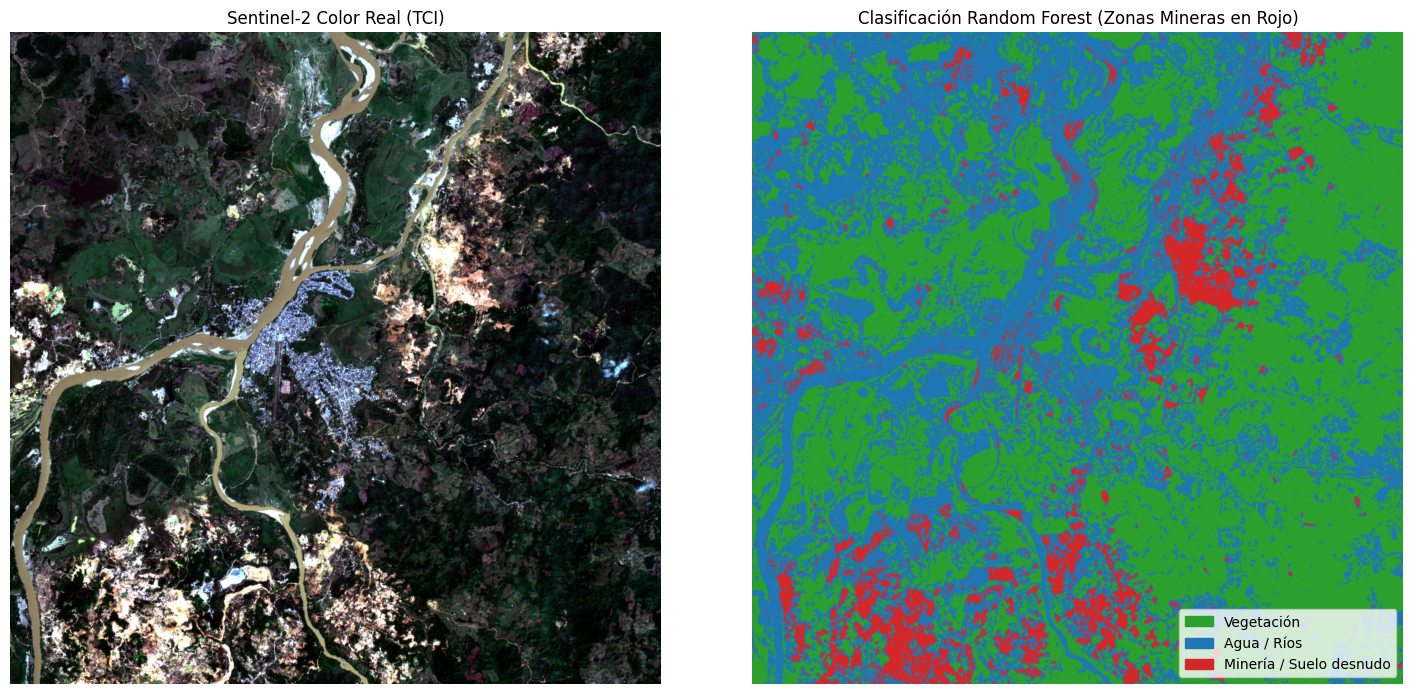

In [ ]:
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    
print("Ajustando (entrenando) el modelo...")
rf.fit(X_train, y_train)

print("Prediciendo clases para el 100% de la imagen...")
predictions_valid = rf.predict(features_valid)

# Devolver el vector 1D a la imagen 2D original
img_shape = ndvi.shape
prediction_map = np.full(img_shape, -1, dtype=int)
prediction_map.flat[valid_idx] = predictions_valid

print("\nGenerando mapa final...")
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Imagen a Color Real (compuesta por RGB y normalizada para que se vea bien)
def normalize_band(b):
    p2, p98 = np.percentile(b, 2), np.percentile(b, 98)
    return np.clip((b - p2) / (p98 - p2), 0, 1)
    
rgb = np.dstack((normalize_band(b04), normalize_band(b03), normalize_band(b02)))
axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 Color Real (TCI)")
axes[0].axis("off")

# Mapa Clasificado
cmap = ListedColormap(['#2ca02c', '#1f77b4', '#d62728']) # Verde (Veg), Azul (Agua), Rojo (Mina)
im = axes[1].imshow(prediction_map, cmap=cmap, vmin=0, vmax=2)
axes[1].set_title("Clasificación Random Forest (Zonas Mineras en Rojo)")
axes[1].axis("off")

patches = [
    mpatches.Patch(color='#2ca02c', label='Vegetación'),
    mpatches.Patch(color='#1f77b4', label='Agua / Ríos'),
    mpatches.Patch(color='#d62728', label='Minería / Suelo desnudo')
]
axes[1].legend(handles=patches, loc='lower right')

plt.tight_layout()
plt.show()
